# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy as np
import torch
import torch.nn as nn
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as T

In [2]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cpu')

In [4]:
set_random_seed()

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

In [5]:
link="https://disk.360.yandex.ru/d/oAmJgPESjP33hg"
!wget -O dataset.zip "$(wget -qO- https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=$link | grep -oP '(?<="href":")[^"]+')"

--2025-11-01 21:21:26--  https://downloader.disk.yandex.ru/disk/f5e6c5daa3f795d8e5377157c04ad85b3665d7880c96b00092e651f340808d41/6906b216/fKqInKw3d7bLFOeFnMGnhMU-Am0OwZYgkShFVCMHfRuRjN7sWOEDg7cNxYR_ZynzNkQak_EceScU48YO2gia0B0aqzJ1x841oKKLZxSfT0-r8npumZHI4midPdWhecNq?uid=0&filename=data.zip&disposition=attachment&hash=vdKSa%2BaDwqGPcS9wpLL0aqbcwi38BbbCcd0pn6qTaRIdUHnl7DNmBgkj90dLrRwnRAX03HPYQxcN%2B1YRYcCtZw%3D%3D%3A&limit=0&content_type=application%2Fzip&owner_uid=1130000070147764&fsize=15771850&hid=b448493f9a294048b39b18b1dba9c2b3&media_type=compressed&tknv=v3
Resolving downloader.disk.yandex.ru (downloader.disk.yandex.ru)... 77.88.21.127, 2a02:6b8::2:127
Connecting to downloader.disk.yandex.ru (downloader.disk.yandex.ru)|77.88.21.127|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://s951sas.storage.yandex.net/rdisk/f5e6c5daa3f795d8e5377157c04ad85b3665d7880c96b00092e651f340808d41/6906b216/fKqInKw3d7bLFOeFnMGnhMU-Am0OwZYgkShFVCMHfRuRjN7sWOEDg7cNxYR_Z

Чтобы загрузить файл с Яндекс диска таким способом с яндекс диска мне помогло вот это: https://gist.github.com/Yegorov/dc61c42aa4e89e139cd8248f59af6b3e и предмет операционные системы с моей ОП

In [6]:
!unzip -q dataset.zip
!rm dataset.zip

In [7]:
!ls -1 data/

testing
training


In [8]:
print(" training/:")
!ls -1 data/training | head
print("\n testing/:")
!ls -1 data/testing | head

 training/:
Al_Gore
Ali_Naimi
Al_Sharpton
Amelia_Vega
Ana_Guevara
Ana_Palacio
Angela_Bassett
Antonio_Palocci
Arminio_Fraga
Ben_Affleck

 testing/:
Albert_Costa
Cameron_Diaz
Mohamed_ElBaradei
Steven_Spielberg
Zhu_Rongji


In [9]:
print(" training/Al_Gore/:")
!ls -1 data/training/Al_Gore/

 training/Al_Gore/:
Al_Gore_0001.jpg
Al_Gore_0002.jpg
Al_Gore_0003.jpg
Al_Gore_0004.jpg
Al_Gore_0005.jpg
Al_Gore_0006.jpg
Al_Gore_0007.jpg
Al_Gore_0008.jpg


Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [42]:
train_ds



In [43]:
train_ds.indices

[8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 191,
 192,
 193,
 194,
 195,
 196,
 206,
 207,
 208,
 209,
 210,
 211,
 212,
 213,
 214,
 215,
 216,
 217,
 218,
 219,
 220,
 221,
 222,
 223,
 224,
 225,
 226,
 227,
 228,
 229,
 230,
 231,
 232,
 233,
 234,
 235,
 236,
 237,
 238,
 239,
 240,
 241,
 242,
 243,
 250,


In [5]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
transform = T.Compose([T.ToTensor(), T.Normalize(mean=mean, std=std)])

train_ds_full = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform = transform)

# тут мы еще добавим валидационную выборку. Надо, чтобы один человек лежал либо полностью в train, либо полностью в val
# поэтому будем делить по классам
classes = train_ds_full.classes
class_to_idx = train_ds_full.class_to_idx

all_classes = list(range(len(classes)))
random.shuffle(all_classes)

train_class_num = int(0.8 * len(all_classes))
train_classes = all_classes[:train_class_num]
val_classes = all_classes[train_class_num:]

train_idx = [i for i, (_, label) in enumerate(train_ds_full.imgs) if label in train_classes]
val_idx = [i for i, (_, label) in enumerate(train_ds_full.imgs) if label in val_classes]

train_ds = torch.utils.data.Subset(train_ds_full, train_idx)
val_ds = torch.utils.data.Subset(train_ds_full, val_idx)

for ds in [train_ds, val_ds]:
    ds.targets = [train_ds_full.targets[i] for i in ds.indices]
    ds.classes = train_ds_full.classes
    ds.class_to_idx = train_ds_full.class_to_idx

d:\Development\Studying\venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [6]:
# давайте проверим, что нет пересечений в людях в train/val
set(train_ds.targets) & set(val_ds.targets) # просто посмотрим пересечение множеств

set()

Оно пусто, все ок.

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

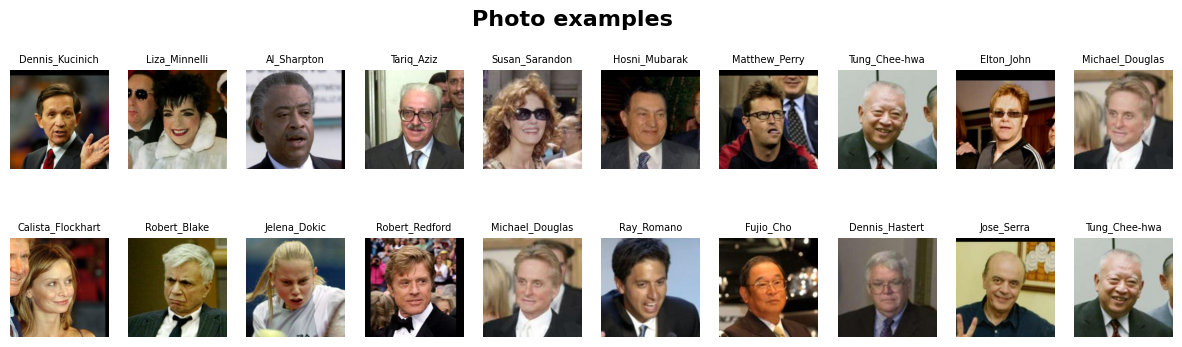

In [12]:
fig, axs = plt.subplots(2, 10, figsize=(15, 4))
plt.suptitle("Photo examples", fontsize=16, fontweight='bold')
for i in range(2):
  for j in range(10):
    img, label = train_ds[random.randint(0, len(train_ds))]
    img = img * std[:, None, None] + mean[:, None, None]
    axs[i][j].imshow(img.permute(1, 2, 0))
    axs[i][j].axis('off')
    axs[i][j].set_title(train_ds.classes[label], fontsize=7)
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

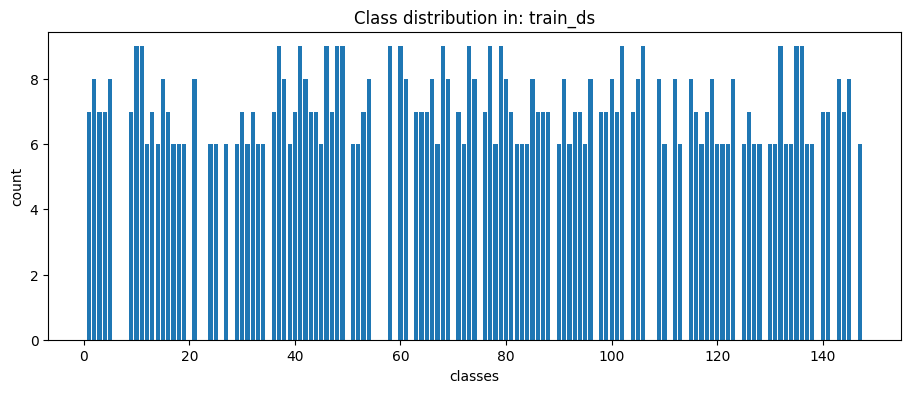

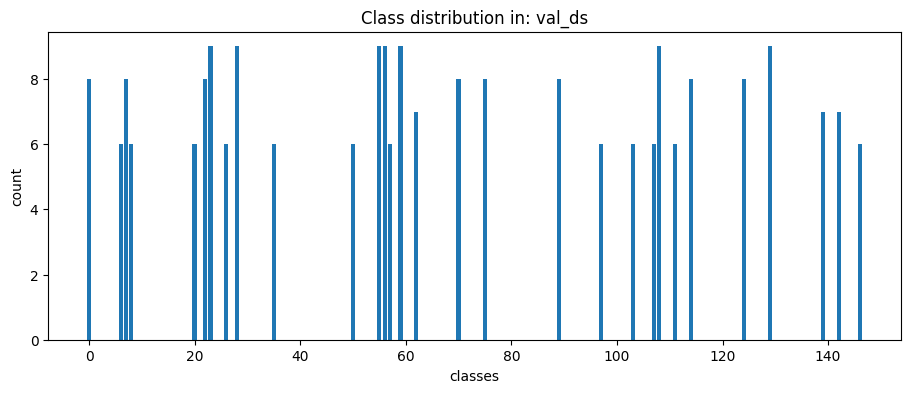

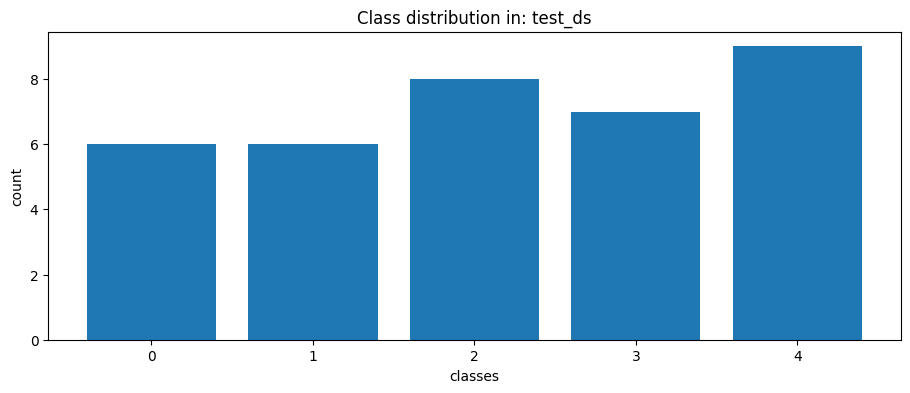

In [13]:
def show_class_distribtion(targets, name):
  plt.figure(figsize=(11, 4))
  classes, counts = np.unique(targets, return_counts=True)
  plt.title(f"Class distribution in: {name}")
  plt.bar(classes, counts)
  plt.xlabel("classes")
  plt.ylabel("count")
  plt.show()

show_class_distribtion(train_ds.targets, "train_ds")
show_class_distribtion(val_ds.targets, "val_ds")
show_class_distribtion(test_ds.targets, "test_ds")

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [14]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
val_pairs = PairDataset(val_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 1163986.72it/s]


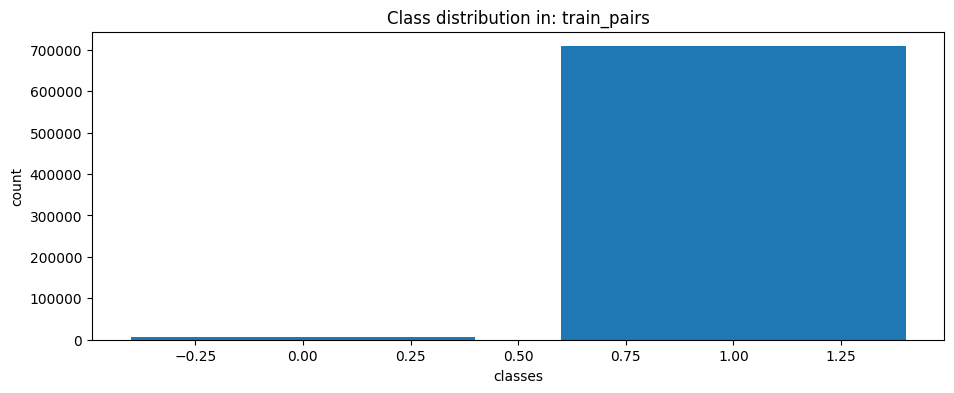

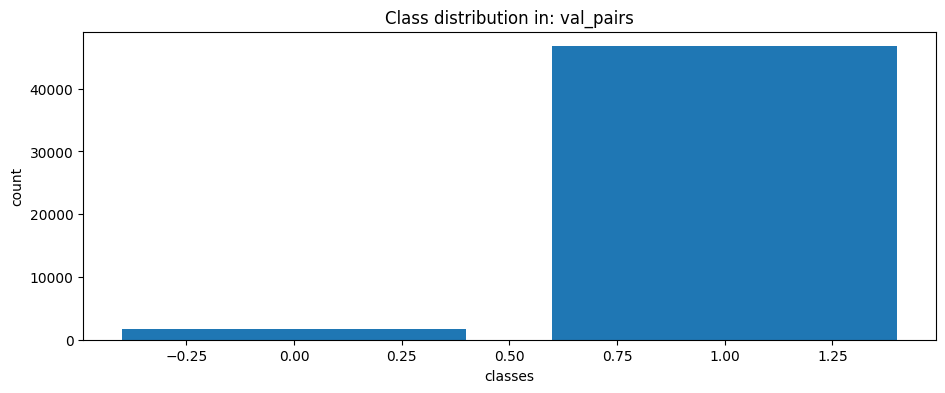

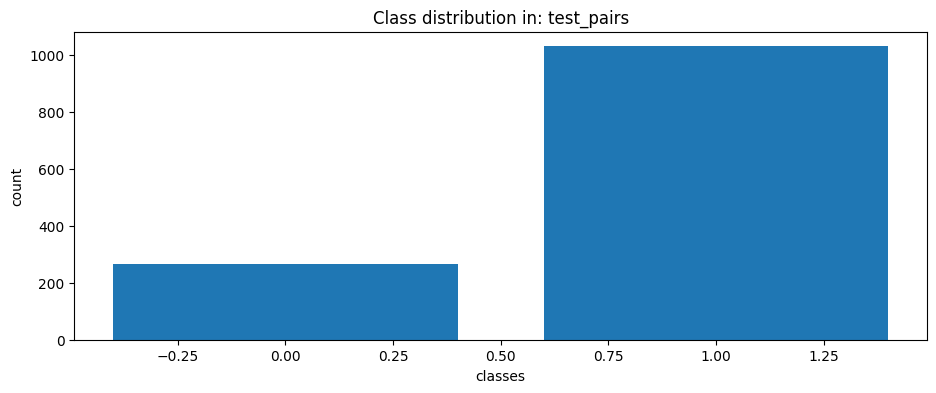

In [15]:
show_class_distribtion(train_pairs.targets, "train_pairs")
show_class_distribtion(val_pairs.targets, "val_pairs")
show_class_distribtion(test_pairs.targets, "test_pairs")

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [16]:
class PairsBalancedSampler(torch.utils.data.Sampler):
  def __init__(self, targets, batch_size):
    self.batch_size = batch_size
    self.class0_idxs = np.where(targets == 0)[0]
    self.class1_idxs = np.where(targets == 1)[0]
    self.max_len = max(len(self.class0_idxs), len(self.class1_idxs))
    self.batch_num = (2 * self.max_len + self.batch_size - 1) // self.batch_size

  def __iter__(self):
    class0_perm = np.random.permutation(self.class0_idxs)
    class1_perm = np.random.permutation(self.class1_idxs)

    half_batch_size = self.batch_size // 2
    half_batches_num = half_batch_size * self.batch_num

    if len(class0_perm) < half_batches_num:
      class0_perm = np.resize(class0_perm, half_batches_num)
    if len(class1_perm) < half_batches_num:
      class1_perm = np.resize(class1_perm, half_batches_num)

    class0_perm = class0_perm[:half_batches_num]
    class1_perm = class1_perm[:half_batches_num]

    for i in range(self.batch_num):
      start = i * half_batch_size
      end = start + half_batch_size

      batch = np.concatenate([class0_perm[start:end], class1_perm[start:end]])
      np.random.shuffle(batch)
      yield from batch.tolist()

  def __len__(self):
    return self.batch_num * self.batch_size

In [17]:
train_pairs_sampler = PairsBalancedSampler(np.array(train_pairs.targets), 32)
val_pairs_sampler = PairsBalancedSampler(np.array(val_pairs.targets), 32)

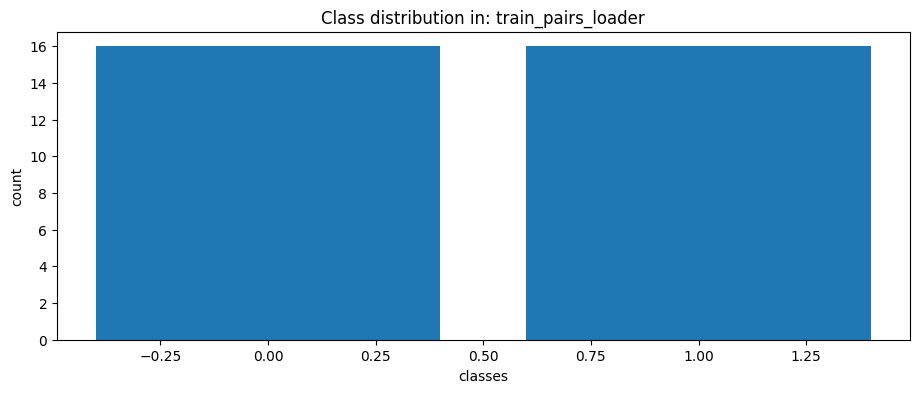

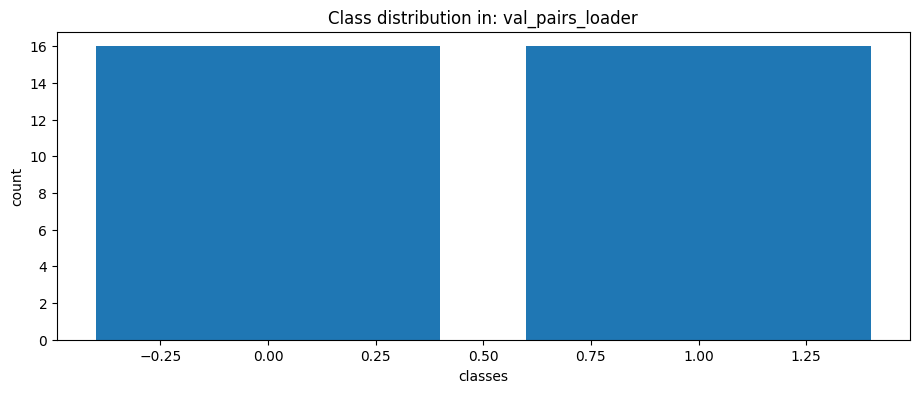

In [18]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler = train_pairs_sampler)
val_pairs_loader = torch.utils.data.DataLoader(val_pairs, batch_size = 32, sampler = val_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2], "train_pairs_loader")
show_class_distribtion(next(iter(val_pairs_loader))[2], "val_pairs_loader")

Возьмем функции для обучения с прошлого семинара, также будем логировать все в wandb. Ссылка на результаты: https://wandb.ai/dpechenin-org/dl-iad-hw-2/workspace?nw=nwuserdpechenin

In [ ]:
# будем использвать wandb для логирования результатов обучения нейросетей
# wandb_project = None
wandb_project = 'dl-iad-hw-2'
import wandb
wandb.login()

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [ ]:
train_pairs[0][0].shape

torch.Size([3, 250, 250])

In [ ]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )

        self.head = nn.Sequential(
            nn.Linear(32 * 30 * 30 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image1, image2):
        out1 = self.backbone(image1)
        out2 = self.backbone(image2)
        pred = self.head(torch.cat([out1, out2], dim=1)).squeeze(1)
        return pred

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [79]:
# возьмем функции для построения графиков из первого семинаров, немного изменим под нашу задачу
import seaborn as sns
from IPython.display import clear_output
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, val_losses, train_roc_aucs, val_roc_aucs):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='validation')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_roc_aucs) + 1), train_roc_aucs, label='train')
    axs[1].plot(range(1, len(val_roc_aucs) + 1), val_roc_aucs, label='validation')
    axs[1].set_ylabel('roc_auc')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [17]:
from sklearn.metrics import roc_auc_score
def training_epoch(model, optimizer, criterion, train_loader, early_stop=1, tqdm_desc=None, wandb_project=None):
    """ One training epoch
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        early_stop – fraction [0, 1] of total batches after which to stop training early
        tqdm_desc - message for tqdm
        wandb_project - name of project in wandb (if None - there will be no wandb project)
    ----------
    returns:
        epoch_loss - loss during this epoch
        epoch_roc_auc - roc-auc during this epoch
    """

    early_stop = int(len(train_loader) * early_stop)
    epoch_loss = 0.0
    total_samples = 0
    all_preds, all_targets = [], []
    model.train()
    for i, (image1, image2, y_batch) in enumerate(tqdm.tqdm(train_loader, desc=tqdm_desc, total=early_stop)):
      if i >= early_stop:
        break
      image1 = image1.to(device)
      image2 = image2.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      logits = model(image1, image2)
      loss = criterion(logits, y_batch.float())
      loss.backward()
      optimizer.step()

      total_samples += y_batch.shape[0]

      all_preds.append(torch.sigmoid(logits).detach().cpu())
      all_targets.append(y_batch.detach().cpu())

      epoch_loss += loss.item() * y_batch.shape[0]

      if wandb_project:
        wandb.log({"batch-train/loss": loss.item()})

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    epoch_loss /= total_samples
    epoch_roc_auc = roc_auc_score(all_targets, all_preds)

    return epoch_loss, epoch_roc_auc

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, early_stop=1, tqdm_desc=None):
    """ One validation epoch
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        early_stop – fraction [0, 1] of total batches after which to stop training early
        tqdm_desc - message for tqdm
    ----------
    returns:
        val_loss - loss during this epoch
        val_roc_auc - roc-auc during this epoch
    """

    early_stop = int(len(val_loader) * early_stop)
    val_loss = 0.0
    total_samples = 0
    all_preds, all_targets = [], []
    model.eval()
    for i, (image1, image2, y_batch) in enumerate(tqdm.tqdm(val_loader, desc=tqdm_desc, total=early_stop)):
      if i >= early_stop:
        break
      image1 = image1.to(device)
      image2 = image2.to(device)
      y_batch = y_batch.to(device)

      logits = model(image1, image2)
      loss = criterion(logits, y_batch.float())

      total_samples += y_batch.shape[0]

      all_preds.append(torch.sigmoid(logits).cpu())
      all_targets.append(y_batch.detach().cpu())

      val_loss += loss.item() * y_batch.shape[0]

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    val_loss /= total_samples
    val_roc_auc = roc_auc_score(all_targets, all_preds)

    return val_loss, val_roc_auc

@torch.no_grad()
def predict_proba(model, data_loader):
    """ Model predictions (probabilities)
    params:
        model - torch.nn.Module to be evaluated on test set
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains probabilities for test objects
    """
    model.eval()
    predicts = []
    for image1, image2, _ in data_loader:
        image1 = image1.to(device)
        image2 = image2.to(device)
        predicts.append(torch.sigmoid(model(image1, image2)).cpu())

    predicts = torch.cat(predicts)
    return predicts

@torch.no_grad()
def predict(model, data_loader, threshold=0.5):
    """ Model preictions (classes)
    params:
        model - torch.nn.Module to be evaluated on test set
        data_loader - torch.utils.data.Dataloader with test set
        threshold - threshold for classification
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = []
    for image1, image2, _ in data_loader:
        image1 = image1.to(device)
        image2 = image2.to(device)
        predicts.append(torch.sigmoid(model(image1, image2)).cpu())

    predicts = torch.cat(predicts)
    predicts = (predicts >= threshold).long()
    return predicts

def train(model, optimizer, criterion, train_loader, val_loader, epochs,
          scheduler=None, early_stop=1, wandb_project=None, save_model=False):
    """ Model training
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
        scheduler - learning rate scheduler
        early_stop – fraction [0, 1] of total batches after which to stop training early
        wandb_project - config for project in wandb (if None - there will be no wandb project)
        save_model = save model weights to wandb, wandb_project nedded
    """

    train_losses, train_roc_aucs, val_losses, val_roc_aucs = [], [], [], []

    if wandb_project:
        wandb.init(**wandb_project)
        wandb.watch(model)

    for epoch in range(1, epochs + 1):
      train_loss, train_roc_auc = training_epoch(
          model, optimizer, criterion, train_loader, early_stop,
          tqdm_desc=f'Training {epoch}/{epochs}',
          wandb_project=wandb_project
      )
      val_loss, val_roc_auc = validation_epoch(
          model, criterion, val_loader, early_stop,
          tqdm_desc=f'Validating {epoch}/{epochs}'
      )

      train_losses.append(train_loss)
      train_roc_aucs.append(train_roc_auc)
      val_losses.append(val_loss)
      val_roc_aucs.append(val_roc_auc)

      if scheduler:
        scheduler.step()

      if wandb_project:
        wandb.log({
            "train/loss": train_loss,
            "train/roc_auc": train_roc_auc,
            "val/loss": val_loss,
            "val/roc_auc": val_roc_auc
        })

      if wandb_project and save_model:
        artifact = wandb.Artifact(name=wandb_project['name'].replace(" ", "_"), type='model', description=f'Model weights after epoch {epoch}')
        model_path = f'model_epoch_{epoch}.pth'
        torch.save(model.state_dict(), model_path)
        artifact.add_file(model_path)
        wandb.log_artifact(artifact)
        os.remove(model_path)

      plot_losses(train_losses, val_losses, train_roc_aucs, val_roc_aucs)
      print(f"Epoch: {epoch}, loss: {val_loss:.4f}, roc_auc: {val_roc_auc:.4f}")
    return train_losses, train_roc_aucs, val_losses, val_roc_aucs

In [ ]:
LR = 1e-3
EPOCHS = 3

model = ClassificationNet().to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

wandb_model = {
  'project': wandb_project,
  'name': 'ClassificationNet 1st try',
  'config': {
    'architecture': 'ConvNet for classification',
    'learning_rate': LR,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}
if not wandb_project:
  wandb_model = None

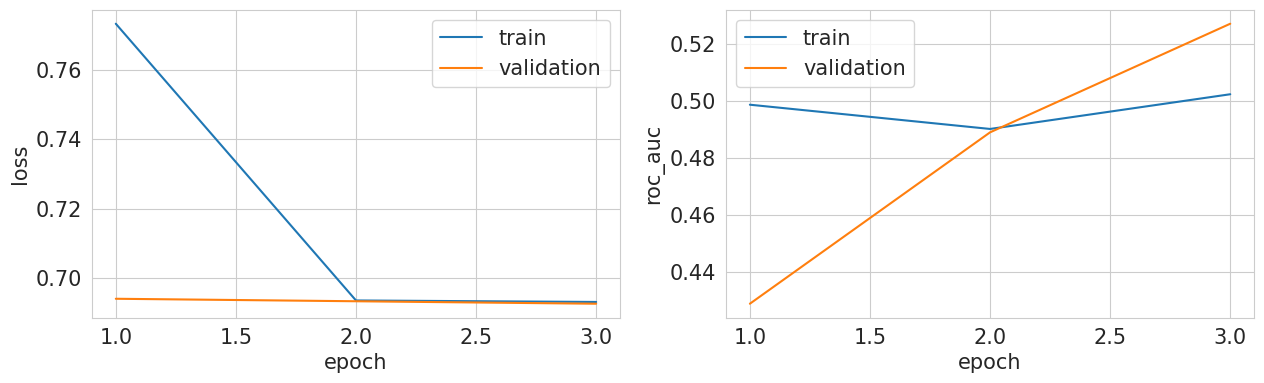

Epoch: 3, loss: 0.6927, roc_auc: 0.5271


In [ ]:
set_random_seed()
# возьмем пока только 0.25% батчей из нашего лоадера, чтобы проверить работает ли вообще
train(model, optim, criterion, train_pairs_loader, val_pairs_loader, EPOCHS, early_stop=0.0025, wandb_project=wandb_model);

Ну вроде все работает, теперь можно продолжить.  
Возьмем теперь только 2.5% батчей из нашего лоадера, так как у нас их очень много.


In [ ]:
LR = 1e-3
EPOCHS = 3

model = ClassificationNet().to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

wandb_model = {
  'project': wandb_project,
  'name': 'ClassificationNet',
  'config': {
    'architecture': 'ConvNet for classification',
    'learning_rate': LR,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}
if not wandb_project:
  wandb_model = None

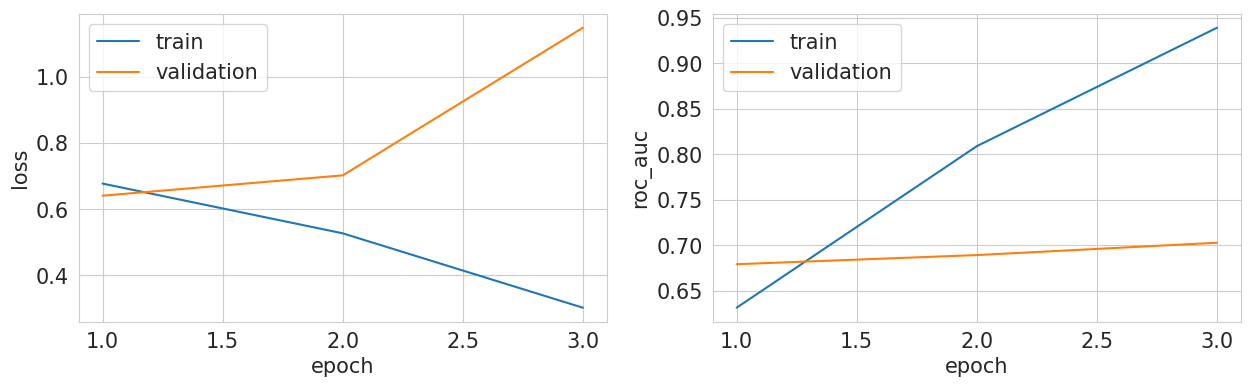

Epoch: 3, loss: 1.1479, roc_auc: 0.7029


In [ ]:
set_random_seed()
train(model, optim, criterion, train_pairs_loader, val_pairs_loader, EPOCHS, early_stop=0.025, wandb_project=wandb_model);

In [ ]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

In [ ]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:03<00:00,  5.80it/s]


(2.5, np.float64(0.9032301627856048))

Ну вообще у нас уже получился требуемый скор на тесте, но мы попробуем еще улучшить нашу модель. Еще вообще на валидации лосс растет, наша модель переобучается.
Добавим BatchNorm.

In [ ]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )

        self.head = nn.Sequential(
            nn.Linear(32 * 30 * 30 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image1, image2):
        out1 = self.backbone(image1)
        out2 = self.backbone(image2)
        pred = self.head(torch.cat([out1, out2], dim=1)).squeeze(1)
        return pred

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

In [ ]:
LR = 1e-3
EPOCHS = 3

model = ClassificationNet().to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

wandb_model = {
  'project': wandb_project,
  'name': 'ClassificationNet BatchNorm',
  'config': {
    'architecture': 'ConvNet for classification with BatchNorm',
    'learning_rate': LR,
    'scheduler': 'None',
    'epochs': EPOCHS,
    'optimizer': 'Adam'
  }
}
if not wandb_project:
  wandb_model = None

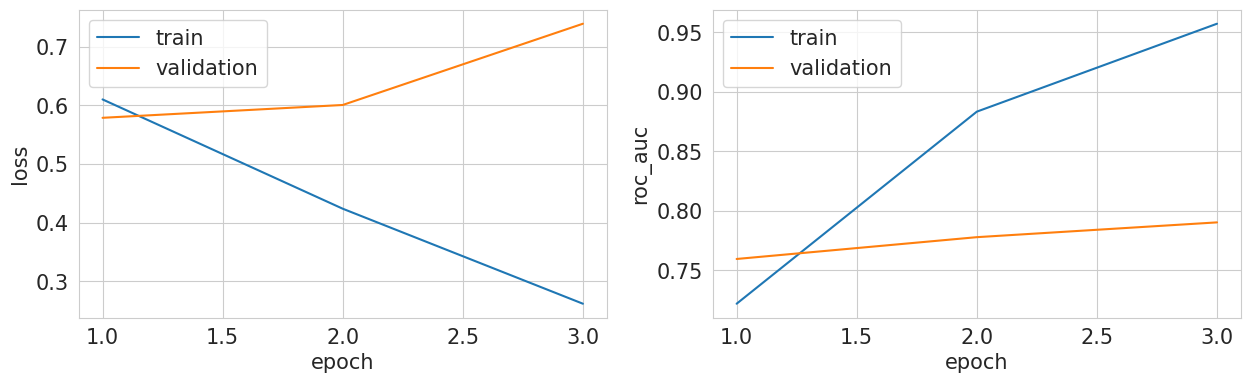

Epoch: 3, loss: 0.7390, roc_auc: 0.7903


In [ ]:
set_random_seed()
train(model, optim, criterion, train_pairs_loader, val_pairs_loader, EPOCHS, early_stop=0.025, wandb_project=wandb_model);

In [ ]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:03<00:00,  5.78it/s]


(2.5, np.float64(0.9283560843857217))

AUC-ROC стал лучше. Теперь опробуем обучить на всех данных + изменим оптимизатор на AdamW, добавим wight_decay, scheduler. Также изменим архитектуру чуть чуть, сделав меньше параметров в сети.

In [ ]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((8, 8)),
            nn.Flatten()
        )

        self.head = nn.Sequential(
            nn.Linear(32 * 8 * 8 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image1, image2):
        out1 = self.backbone(image1)
        out2 = self.backbone(image2)
        pred = self.head(torch.cat([out1, out2], dim=1)).squeeze(1)
        return pred

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

In [ ]:
LR = 1e-3
EPOCHS = 2

model = ClassificationNet().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1, gamma=0.8)
criterion = nn.BCEWithLogitsLoss()

wandb_model = {
  'project': wandb_project,
  'name': 'ClassificationNet BatchNorm final',
  'config': {
    'architecture': 'ConvNet for classification with BatchNorm, Dropout, AdaptiveAvgPooling',
    'learning_rate': LR,
    'scheduler': 'StepLR(step_size=1, gamma=0.8)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

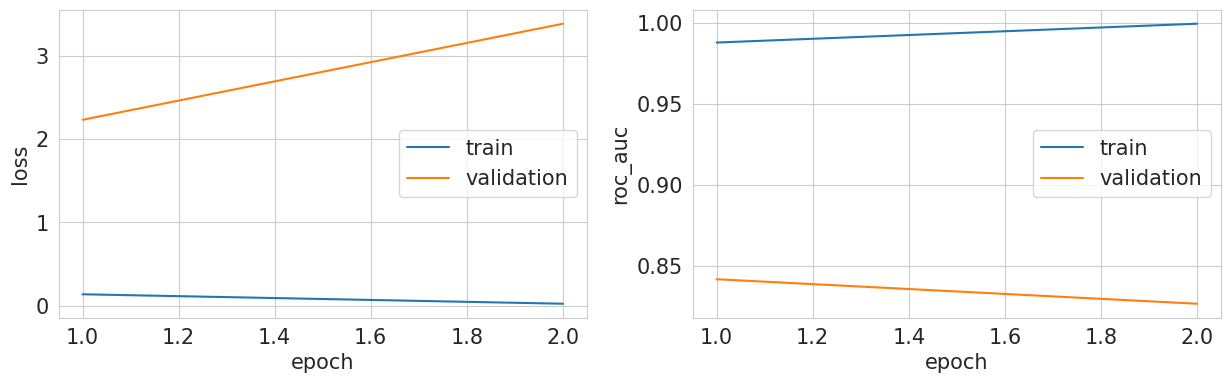

Epoch: 2, loss: 3.3830, roc_auc: 0.8267


In [ ]:
set_random_seed()
train(model, optim, criterion, train_pairs_loader, val_pairs_loader, EPOCHS, scheduler=scheduler,
      early_stop=1, wandb_project=wandb_model, save_model=True);

In [ ]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:03<00:00,  5.68it/s]


(2.5, np.float64(0.9399591211037303))

Видно, что есть переобучение, метрики на валидации стали падать, хотя на трейне все отлично.  


##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

При проведении всех экспериментов мы получили требуемое качество, но видно, что во всех из них есть переобучение. ROC-AUC на train становится равным 1 при обучении на всей выборке, да даже если не на всей он все равно близок к 1. Получается, что сделанные нами модели плохо обощают, а просто выучивают наши данные для обучения.  
Получается, что решать задачу через бинарную классификацию далеко не лучшая идея. Вот причины почему может быть так:  
1.   Наша модель запоминает пары, а не лица. У нас берет и склеиваются эмбеддинги двух фотографий и затем модель по этому большому ветору уже пытается, что-то понять, в итоге она хорошо запомнила наши пары, но вот людей отличать так и не научилась.
2.   У нас слишком много пар получается, где имеются одинаковые лица, в итоге модель очень хорошо запоминает конкретные "легкие" примеры и плохо обощает. Ну и плюсом нужно очень много ресурсов на обучение.
3.   Также, что делать если появиться новый человек. Во-первых, должно быть такое же количество фотографий примерно, во-вторых, надо составлять опять какие-то пары.
4.   Еще если у нас два человека сильно похожи, но в выборке они помечены, как разные, так как в действительности это разные люди, то модель может выдавать все равно на этой картинте большую увереность, что они разные, хотя в этом случае уверенность должна быть меньше, так как они действительно похожи. И наоборот, если люди слишком разные, то увереность может получится маленькая.



### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [19]:
class TripletLoss(nn.Module):
  def __init__(self, margin=0.25):
    super().__init__()
    self.margin = margin

  def forward(self, embeddings, labels):
    distances = torch.cdist(embeddings, embeddings)

    labels = labels.unsqueeze(1)
    pos_mask = (labels == labels.T)
    neg_mask = (labels != labels.T)

    losses = []
    for a in range(embeddings.shape[0]):
      pos_idx = pos_mask[a].clone()
      pos_idx[a] = False
      dist_pos = distances[a][pos_idx]
      dist_neg = distances[a][neg_mask[a]]

      if len(dist_pos) == 0 or len(dist_neg) == 0:
        continue

      loss = dist_pos.unsqueeze(1) - dist_neg.unsqueeze(0) + self.margin
      loss = torch.maximum(loss, torch.zeros_like(loss))
      losses.append(loss.mean())

    if len(losses) == 0:
      return torch.tensor(0.0, requires_grad=True).to(embeddings.device)

    return torch.stack(losses).mean()

In [21]:
criterion = TripletLoss(margin=0.25)

In [22]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

В качестве датасета будем использовать стандартный ImageFolder (train_ds, val_ds, test_ds из самого начала). Сначала напишем новый sampler. Семплер будет у нас выдавать батчи так, что в каждом батче будет некоторое количество фотографий каждого человека, так как иначе как нам вычислять нормально triplet loss.

In [23]:
import math
class TripletSampler(torch.utils.data.sampler.Sampler):
  def __init__(self, labels, persons_num_in_batch, photos_num_per_person):
    self.labels = np.array(labels)
    self.labels_unique = np.unique(self.labels)
    self.persons_num = persons_num_in_batch
    self.photos_num = photos_num_per_person
    self.batch_size = self.persons_num * self.photos_num
    self.label_to_idx = {l: np.where(self.labels == l)[0] for l in self.labels_unique}

  def __len__(self):
    return len(self.labels)

  def __iter__(self):
    classes = np.copy(self.labels_unique)
    np.random.shuffle(classes)

    batch = []
    persons_in_batch = 0
    for c in classes:
      cls_idx = self.label_to_idx[c]
      if len(cls_idx) < self.photos_num:
        cls_idx = np.tile(cls_idx, self.photos_num // len(cls_idx) + 1)
      chosen = np.random.choice(cls_idx, self.photos_num, replace=False)
      batch.extend(chosen)
      persons_in_batch += 1

      if len(batch) >= self.batch_size:
        yield from batch
        batch = []
        persons_in_batch = 0

    if batch:
      yield from batch

In [24]:
train_sampler = TripletSampler(train_ds.targets, 8, 8)
val_sampler = TripletSampler(val_ds.targets, 8, 8)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, sampler=val_sampler)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64, shuffle=False)

Для тестирования будем использовать только старый лоадеры, потому что нам там надо попарно считать расстояния.

Перепишем функции для обучения. Будем отдельно считать на валидации ROC-AUC, используя парный лоадер, и просто триплет лосс используя обычный лоадер.

In [113]:
import seaborn as sns
from IPython.display import clear_output
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, val_losses, val_roc_aucs, epochs=None):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='validation')
    axs[0].set_ylabel('loss')
    if epochs:
      axs[1].plot(epochs, val_roc_aucs, label='validation')
    else:
      axs[1].plot(range(1, len(val_roc_aucs) + 1), val_roc_aucs, label='validation')
    axs[1].set_ylabel('roc_auc')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [24]:
from sklearn.metrics import roc_auc_score
def training_epoch(model, optimizer, criterion, train_loader, early_stop=1, tqdm_desc=None, wandb_project=None):
    """ One training epoch
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        early_stop – fraction [0, 1] of total batches after which to stop training early
        tqdm_desc - message for tqdm
        wandb_project - name of project in wandb (if None - there will be no wandb project)
    ----------
    returns:
        epoch_loss - loss during this epoch
    """

    early_stop = int(len(train_loader) * early_stop)
    epoch_loss = 0.0
    total_samples = 0
    model.train()
    for i, (image, y_batch) in enumerate(tqdm.tqdm(train_loader, desc=tqdm_desc, total=early_stop)):
      if i >= early_stop:
        break
      image = image.to(device)
      y_batch = y_batch.to(device)
      optimizer.zero_grad()
      emb = model(image)
      loss = criterion(emb, y_batch)
      loss.backward()
      optimizer.step()

      total_samples += y_batch.shape[0]
      epoch_loss += loss.item() * y_batch.shape[0]

      if wandb_project:
        wandb.log({"batch-train/loss": loss.item()})

    epoch_loss /= total_samples

    return epoch_loss

@torch.no_grad()
def validation_epoch_loss(model, criterion, val_loader, early_stop=1, tqdm_desc=None):
    """ One validation epoch for loss
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        early_stop – fraction [0, 1] of total batches after which to stop training early
        tqdm_desc - message for tqdm
    ----------
    returns:
        val_loss - loss during this epoch
    """

    early_stop = int(len(val_loader) * early_stop)
    val_loss = 0.0
    total_samples = 0
    model.eval()
    for i, (image, y_batch) in enumerate(tqdm.tqdm(val_loader, desc=tqdm_desc, total=early_stop)):
      if i >= early_stop:
        break
      image = image.to(device)
      y_batch = y_batch.to(device)
      emb = model(image)
      loss = criterion(emb, y_batch)

      total_samples += y_batch.shape[0]
      val_loss += loss.item() * y_batch.shape[0]

    val_loss /= total_samples

    return val_loss

def compute_dist(emb1, emb2):
  return ((emb1 - emb2) ** 2).sum(dim = 1)

@torch.no_grad()
def validation_epoch_roc_auc(model, compute_dist, val_loader, early_stop=1, tqdm_desc=None):
    """ One validation epoch for computing roc-auc
    params:
        model - torch.nn.Module to be fitted
        compute_dist - function to compute distance between embeddings
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        early_stop – fraction [0, 1] of total batches after which to stop training early
        tqdm_desc - message for tqdm
    ----------
    returns:
        val_roc_auc - roc-auc during this epoch
    """

    early_stop = int(len(val_loader) * early_stop)
    all_preds, all_targets = [], []
    model.eval()
    for i, (image1, image2, y_batch) in enumerate(tqdm.tqdm(val_loader, desc=tqdm_desc, total=early_stop)):
      if i >= early_stop:
        break
      image1 = image1.to(device)
      image2 = image2.to(device)
      y_batch = y_batch.to(device)

      emb1 = model(image1)
      emb2 = model(image2)

      all_preds.append(compute_dist(emb1.detach().cpu(), emb2.detach().cpu()))
      all_targets.append(y_batch.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    val_roc_auc = roc_auc_score(all_targets, all_preds)

    return val_roc_auc

def train(model, optimizer, criterion, train_loader, val_loader_roc_auc, val_loader_loss, compute_dist,
          epochs, roc_auc_interval=1, scheduler=None, early_stop=1, wandb_project=None, save_model=False):
    """ Model training
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader_roc_auc - torch.utils.data.Dataloader with validation set. Must contains pairs of images.
        val_loader_loss - torch.utils.data.Dataloader with validation set. Must contains separate images.
        compute_dist - function for computing distance between embeddings
        epochs - number of training epochs
        roc_auc_interval - how often to compute the roc_auc_score (epochs). If 2 will count every second epoch. The last epoch always computes.
        scheduler - learning rate scheduler
        early_stop – fraction [0, 1] of total batches after which to stop training early
        wandb_project - config for project in wandb (if None - there will be no wandb project)
        save_model = save model weights to wandb, wandb_project nedded
    """

    train_losses, val_losses, val_roc_aucs = [], [], []

    if wandb_project:
        wandb.init(**wandb_project)
        wandb.watch(model)

    if roc_auc_interval != 1:
      epochs_for_roc_auc_graph = []

    for epoch in range(1, epochs + 1):
      train_loss = training_epoch(
          model, optimizer, criterion, train_loader, early_stop,
          tqdm_desc=f'Training {epoch}/{epochs}',
          wandb_project=wandb_project
      )
      val_loss = validation_epoch_loss(
          model, criterion, val_loader_loss, early_stop,
          tqdm_desc=f'Validating (loss) {epoch}/{epochs}'
      )
      if epoch % roc_auc_interval == 0 or epoch == epochs:
        val_roc_auc = validation_epoch_roc_auc(
            model, compute_dist, val_loader_roc_auc, early_stop,
            tqdm_desc=f'Validating (roc-auc) {epoch}/{epochs}'
        )
        epochs_for_roc_auc_graph.append(epoch)

      train_losses.append(train_loss)
      val_losses.append(val_loss)
      if epoch % roc_auc_interval == 0 or epoch == epochs:
        val_roc_aucs.append(val_roc_auc)

      if scheduler:
        scheduler.step()

      if wandb_project:
        wandb.log({
            "train/loss": train_loss,
            "val/loss": val_loss
        })
        if epoch % roc_auc_interval == 0 or epoch == epochs:
          wandb.log({"val/roc_auc": val_roc_auc})

      if wandb_project and save_model:
        artifact = wandb.Artifact(name=wandb_project['name'].replace(" ", "_"), type='model', description=f'Model weights after epoch {epoch}')
        model_path = f'model_epoch_{epoch}.pth'
        torch.save(model.state_dict(), model_path)
        artifact.add_file(model_path)
        wandb.log_artifact(artifact)
        os.remove(model_path)

      if roc_auc_interval == 1:
        plot_losses(train_losses, val_losses, val_roc_aucs)
      else:
        plot_losses(train_losses, val_losses, val_roc_aucs, epochs_for_roc_auc_graph)
      if epoch % roc_auc_interval == 0 or epoch == epochs:
        print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, val loss: {val_loss:.4f}, val roc_auc: {val_roc_auc:.4f}")
      else:
        print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, val loss: {val_loss:.4f}")
    return train_losses, val_losses, val_roc_aucs

In [73]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

Возьмем следующую архитектуру в качестве первой. Она довольно похожу на наши предыдущие.

In [69]:
class EmbeddingNet(nn.Module):
  def __init__(self):
    super().__init__()

    self.backbone = nn.Sequential(
      nn.Conv2d(3, 16, 3, stride=2, padding=1),
      nn.BatchNorm2d(16),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(16, 32, 3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(32, 64, 3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.AdaptiveAvgPool2d((8, 8)),
      nn.Flatten()
    )

    self.linear = nn.Linear(64 * 8 * 8, 100)

  def forward(self, x):
    out = self.backbone(x)
    out = self.linear(out)
    out = nn.functional.normalize(out, p=2, dim=1)
    return out

In [70]:
LR = 1e-3
EPOCHS = 2

model = EmbeddingNet().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1, gamma=0.8)
criterion = TripletLoss(margin=0.25)

wandb_model = {
  'project': wandb_project,
  'name': 'EmbeddingNet 1st try',
  'config': {
    'architecture': 'EmbeddingNet',
    'learning_rate': LR,
    'scheduler': 'StepLR(step_size=1, gamma=0.8)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

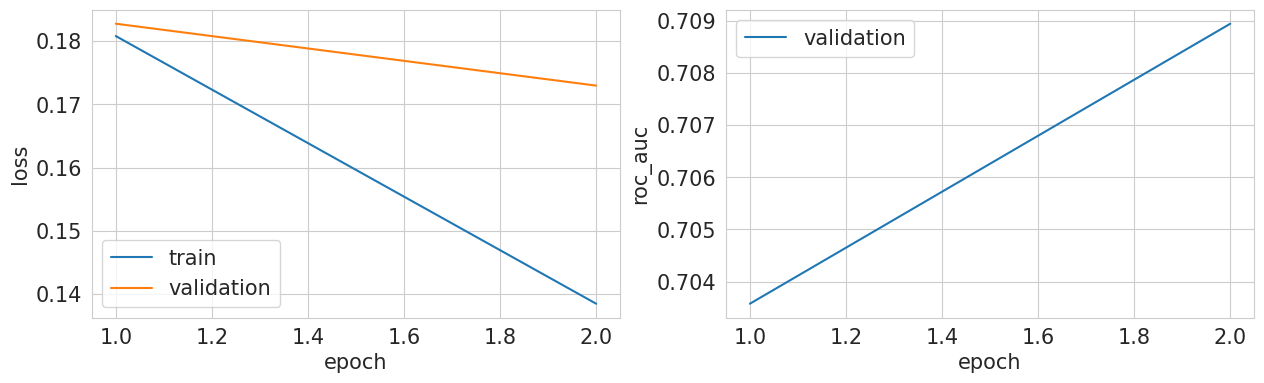

Epoch: 2, train loss: 0.1385, val loss: 0.1730, val roc_auc: 0.7089


In [71]:
set_random_seed()
train(model, optim, criterion, train_loader, val_pairs_loader, val_loader, compute_dist, EPOCHS,
      scheduler=scheduler, early_stop=0.5, wandb_project=wandb_model);

In [75]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:04<00:00,  5.20it/s]


(np.float64(0.9279509453244761), np.float64(0.8463975472662238))

Требуемое качество не получили, но так обучение идет. Для начала попробуем обучить на всем датасете и сделаем побольше эпох.

In [76]:
LR = 1e-3
EPOCHS = 6

model = EmbeddingNet().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1, gamma=0.8)
criterion = TripletLoss(margin=0.25)

wandb_model = {
  'project': wandb_project,
  'name': 'EmbeddingNet 1st try',
  'config': {
    'architecture': 'EmbeddingNet',
    'learning_rate': LR,
    'scheduler': 'StepLR(step_size=1, gamma=0.8)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

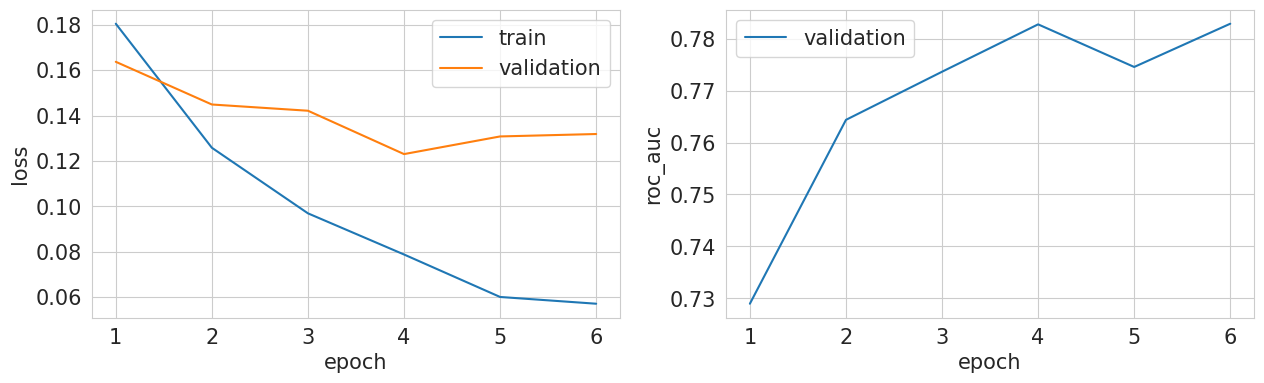

Epoch: 6, train loss: 0.0571, val loss: 0.1319, val roc_auc: 0.7829


In [77]:
set_random_seed()
train(model, optim, criterion, train_loader, val_pairs_loader, val_loader, compute_dist, EPOCHS,
      scheduler=scheduler, early_stop=1, wandb_project=wandb_model);

In [78]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:03<00:00,  5.88it/s]


(np.float64(2.736550113146945), np.float64(0.9368275056573473))

Стало лучше, но еще недостаточно, теперь давайте попробуем добавить residual connections.

In [91]:
class ResEmbeddingNet(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Sequential(
      nn.Conv2d(3, 16, 3, stride=2, padding=1),
      nn.BatchNorm2d(16),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )

    self.conv2 = nn.Sequential(
      nn.Conv2d(16, 32, 3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )

    self.conv3 = nn.Sequential(
      nn.Conv2d(32, 64, 3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU()
    )

    self.linear = nn.Linear(64 * 8 * 8, 100)

    self.shortcut2 = nn.Conv2d(16, 32, 1, stride=2)
    self.shortcut3 = nn.Conv2d(32, 64, 1)

  def forward(self, x):
    out1 = self.conv1(x)

    out2 = self.conv2(out1)
    out2 = nn.functional.relu(out2 + self.shortcut2(out1))

    out3 = self.conv3(out2)
    out3 = nn.functional.relu(out3 + self.shortcut3(out2))
    out3 = nn.functional.adaptive_avg_pool2d(out3, (8, 8))

    out = torch.flatten(out3, 1)
    out = self.linear(out)
    out = nn.functional.normalize(out, p=2, dim=1)
    return out

In [92]:
LR = 1e-3
EPOCHS = 6

model = ResEmbeddingNet().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1, gamma=0.8)
criterion = TripletLoss(margin=0.25)

wandb_model = {
  'project': wandb_project,
  'name': 'ResEmbeddingNet',
  'config': {
    'architecture': 'ResEmbeddingNet',
    'learning_rate': LR,
    'scheduler': 'StepLR(step_size=1, gamma=0.8)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

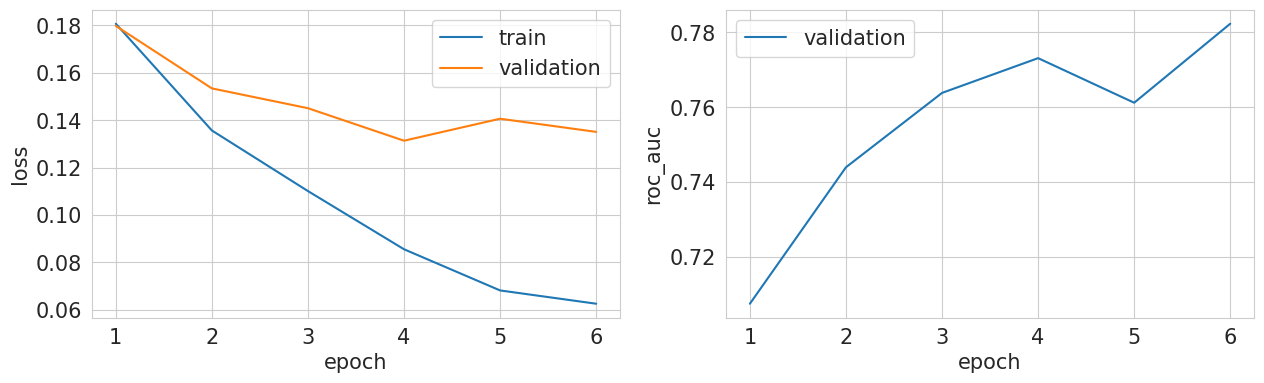

Epoch: 6, train loss: 0.0626, val loss: 0.1351, val roc_auc: 0.7823


In [93]:
set_random_seed()
train(model, optim, criterion, train_loader, val_pairs_loader, val_loader, compute_dist, EPOCHS,
      scheduler=scheduler, early_stop=1, wandb_project=wandb_model, save_model=True);

In [94]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:03<00:00,  5.62it/s]


(np.float64(2.5245638367764056), np.float64(0.9262281918388203))

Ну residual conections не помогли. Так ну давайте оставим только один residual connection, и чуть чуть расширим нашу архитектуру, будем обучать большое кол-во эпох, но roc-auc на валидации будем считать реже.

In [16]:
class ResEmbeddingNetv2(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Sequential(
      nn.Conv2d(3, 32, 3, stride=2, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )

    self.conv2 = nn.Sequential(
      nn.Conv2d(32, 64, 3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )

    self.conv3 = nn.Sequential(
      nn.Conv2d(64, 128, 3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU()
    )

    self.avgpool = nn.AdaptiveAvgPool2d((8, 8))
    self.shortcut = nn.Conv2d(32, 128, 1, stride=2)

    self.linear = nn.Linear(128 * 8 * 8, 128)

  def forward(self, x):
    out1 = self.conv1(x)

    out2 = self.conv2(out1)
    out2 = nn.functional.relu(out2)

    out3 = self.conv3(out2)
    out3 = nn.functional.relu(out3 + self.shortcut(out1))
    out3 = self.avgpool(out3)

    out = torch.flatten(out3, 1)
    out = self.linear(out)
    out = nn.functional.normalize(out, p=2, dim=1)
    return out

In [108]:
LR = 1e-3
EPOCHS = 10

model = ResEmbeddingNetv2().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=1, gamma=0.8)
criterion = TripletLoss(margin=0.25)

wandb_model = {
  'project': wandb_project,
  'name': 'ResEmbeddingNetv2',
  'config': {
    'architecture': 'ResEmbeddingNetv2',
    'learning_rate': LR,
    'scheduler': 'StepLR(step_size=1, gamma=0.8)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

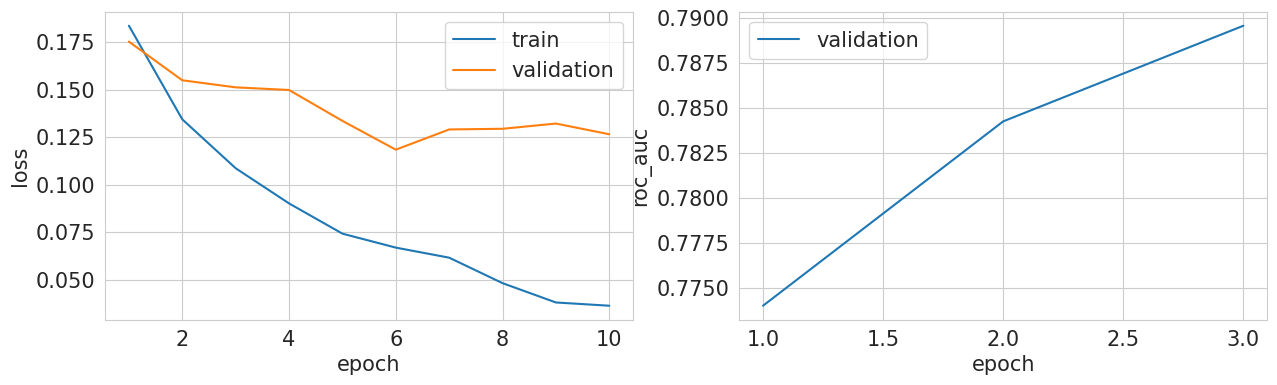

Epoch: 10, train loss: 0.0363, val loss: 0.1266, val roc_auc: 0.7896


In [109]:
set_random_seed()
train(model, optim, criterion, train_loader, val_pairs_loader, val_loader, compute_dist, EPOCHS,
      roc_auc_interval=4, scheduler=scheduler, early_stop=1, wandb_project=wandb_model, save_model=True);

In [110]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:04<00:00,  5.24it/s]


(np.float64(2.850719030586173), np.float64(0.9425359515293087))

Немного не хватило. Теперь попробуем использовать другой scheduler + начальный LR изменим чуть чуть + количество эпох увеличим.

In [115]:
LR = 2e-3
EPOCHS = 12

model = ResEmbeddingNetv2().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=1e-5)
criterion = TripletLoss(margin=0.25)

wandb_model = {
  'project': wandb_project,
  'name': 'ResEmbeddingNetv2 exp2',
  'config': {
    'architecture': 'ResEmbeddingNetv2',
    'learning_rate': LR,
    'scheduler': 'CosineAnnealingLR(T_max=EPOCHS, eta_min=1e-5)',
    'epochs': EPOCHS,
    'optimizer': 'AdamW(weight_decay=1e-4)'
  }
}
if not wandb_project:
  wandb_model = None

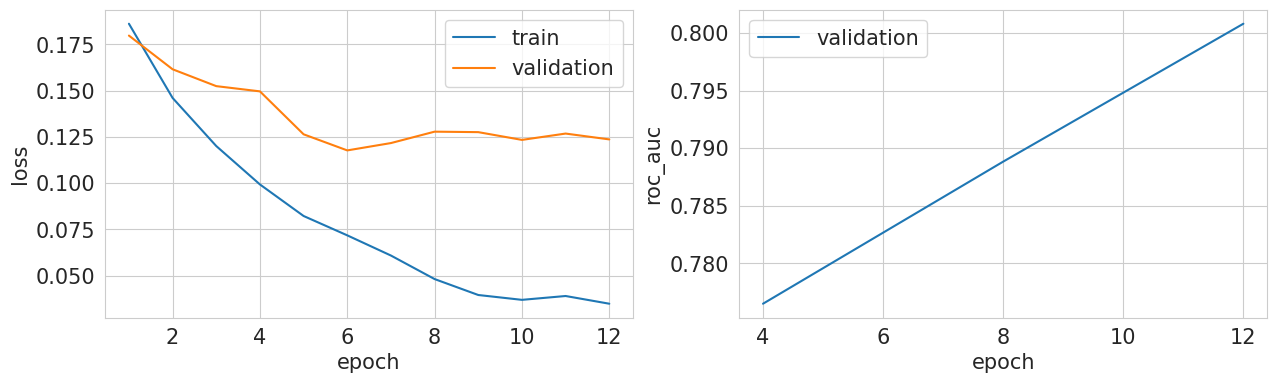

Epoch: 12, train loss: 0.0348, val loss: 0.1236, val roc_auc: 0.8008


In [116]:
set_random_seed()
train(model, optim, criterion, train_loader, val_pairs_loader, val_loader, compute_dist, EPOCHS,
      roc_auc_interval=4, scheduler=scheduler, early_stop=1, wandb_project=wandb_model, save_model=True);

In [117]:
auc = get_auc_roc(model)
get_score(auc), auc

100%|██████████| 21/21 [00:04<00:00,  5.24it/s]


(3, np.float64(0.9579677348711585))

Ура, требуемое качество получить мы смогли.

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

Сначала скачаем нашу обученную модель с wandb, а потом обучим:

In [ ]:
api = wandb.Api()
artifact = api.artifact("...", type="model")
artifact.download()

wandb:   1 of 1 files downloaded.  


'/content/artifacts/ResEmbeddingNetv2_exp2:v11'

In [18]:
model = ResEmbeddingNetv2().to(device)
model_path = "/content/artifacts/ResEmbeddingNetv2_exp2:v11/model_epoch_12.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

ResEmbeddingNetv2(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(8, 8))
  (shortcut): Conv2d(32, 128, kernel_size=(1, 1), stride=(2, 2))
  (linear): Linear(in_features=8192, out_features=128, bias=True)
)

Теперь вычислим эмбеддинги для вообще всех фото.

In [19]:
datasets = [train_ds_full, test_ds]
embeddings = []
with torch.no_grad():
    for ds in datasets:
        for path, (image, idx) in zip(ds.samples, ds):
            image = image.unsqueeze(0).to(device)
            emb = model(image).squeeze(0).cpu()
            embeddings.append((ds.classes[idx], emb, path))

In [20]:
all_embs_tensor = torch.stack([emb for _, emb, _ in embeddings])

In [21]:
from PIL import Image
def get_similar_person(image_path, name, embeddings, all_embs_tensor):
  image = Image.open(image_path).convert("RGB")
  image_t = transform(image).unsqueeze(0).to(device)
  with torch.no_grad():
    query_emb = model(image_t).cpu()
    distances = compute_dist(query_emb, all_embs_tensor)
    min_idx = distances.argmin().item()

  closest_name,  _, closest_path = embeddings[min_idx]
  closest_img = Image.open(closest_path[0]).convert("RGB")

  fig, axs = plt.subplots(1, 2, figsize=(6, 3))
  axs[0].imshow(image)
  axs[0].set_title(name)
  axs[0].axis("off")

  axs[1].imshow(closest_img)
  axs[1].set_title(f"{closest_name}")
  axs[1].axis("off")

  plt.tight_layout()
  plt.show()

In [ ]:
get_similar_person("/content/myphoto.jpeg", "Me", embeddings, all_embs_tensor)